In [ ]:
%pip install -r requirements.txt -q

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


...


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re, joblib, warnings, nltk
from tqdm import tqdm

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

import pymorphy3
from razdel import tokenize
from nltk.corpus import stopwords

nltk.download('stopwords', quiet=True)
stop_words = set(stopwords.words('russian'))
morph = pymorphy3.MorphAnalyzer(lang='ru')

from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.models import Word2Vec, FastText

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, accuracy_score, 
    precision_score, recall_score, f1_score, confusion_matrix
)

In [3]:
data = pd.read_parquet("hf://datasets/d0rj/geo-reviews-dataset-2023/data/train-00000-of-00001-49261e4e5a35a5a0.parquet", engine='pyarrow')
data

,address,name_ru,rating,rubrics,text
0,"Екатеринбург, ул. Московская / ул. Волгоградск...",Московский квартал,3,Жилой комплекс,Московский квартал 2.\nШумно : летом по ночам ...
1,"Московская область, Электросталь, проспект Лен...",Продукты Ермолино,5,Магазин продуктов;Продукты глубокой заморозки;...,"Замечательная сеть магазинов в общем, хороший ..."
2,"Краснодар, Прикубанский внутригородской округ,...",LimeFit,1,Фитнес-клуб,"Не знаю смутят ли кого-то данные правила, но я..."
3,"Санкт-Петербург, проспект Энгельса, 111, корп. 1",Snow-Express,4,Пункт проката;Прокат велосипедов;Сапсёрфинг,Хорошие условия аренды. \nДружелюбный персонал...
4,"Тверь, Волоколамский проспект, 39",Студия Beauty Brow,5,"Салон красоты;Визажисты, стилисты;Салон бровей...",Топ мастер Ангелина топ во всех смыслах ) Немн...
...,...,...,...,...,...
499995,"Москва, Южный административный округ, район Би...",Бирюлёво-Пассажирская,4,Железнодорожная станция,"Охрана кривая но добрая, двери не закрываются ..."
499996,"Москва, Южный административный округ, район Би...",Бирюлёво-Пассажирская,4,Железнодорожная станция,По сравнению со многими современными платформа...
499997,"Новосибирск, Коммунистическая улица, 48А",None,5,"Бар, паб","Приятная атмосфера, прекрасное вино, волшебная..."
499998,"Астраханская область, Харабалинский район",Сарай-Бату,5,Достопримечательность,Был с семьёй 13.06.23 Отличное место. Рекоменд...


Проведем неглубокий EDA на всём датасете

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   address  500000 non-null  object
 1   name_ru  499030 non-null  object
 2   rating   500000 non-null  int64 
 3   rubrics  500000 non-null  object
 4   text     500000 non-null  object
dtypes: int64(1), object(4)
memory usage: 19.1+ MB


In [5]:
data.isnull().sum()

address      0
name_ru    970
rating       0
rubrics      0
text         0
dtype: int64

Посмотрим есть ли дубликаты

In [6]:
data[data.duplicated(keep = False)]

,address,name_ru,rating,rubrics,text
124085,"Красноярск, Ястынская улица, 14",Спарта Маркет,5,Автоакустика;Тонирование автостёкол;Плёнки арх...,"Хорошие консультанты, вежливые.\nВсе помогли ,..."
124087,"Красноярск, Ястынская улица, 14",Спарта Маркет,5,Автоакустика;Тонирование автостёкол;Плёнки арх...,"Хорошие консультанты, вежливые.\nВсе помогли ,..."


Есть 1 дублирующаяся строка. Удалим её

In [7]:
data = data.drop_duplicates()

In [8]:
data['rating'].describe()

count    499999.000000
mean          4.481599
std           1.146250
min           0.000000
25%           5.000000
50%           5.000000
75%           5.000000
max           5.000000
Name: rating, dtype: float64

Посмотрим распределение оценок в датасете

In [9]:
data['rating'].value_counts().sort_index()

rating
0       200
1     34351
2     12088
3     21686
4     41160
5    390514
Name: count, dtype: int64

<BarContainer object of 6 artists>

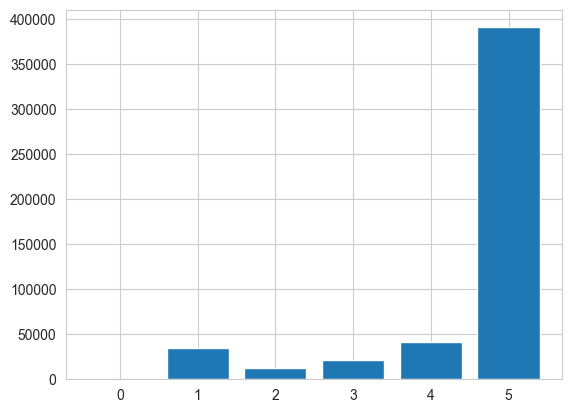

In [10]:
plt.bar(data['rating'].value_counts().index, data['rating'].value_counts().values)

По графику видно что в датасете присутствует сильный дисбаланс оценок.

Для начала посмотрим отзывы где оценка 0

In [11]:
data[data['rating'] == 0]

,address,name_ru,rating,rubrics,text
1907,"Республика Карелия, Суоярви, улица Шельшакова, 1",Гостиница Карелия,0,Гостиница,"Гостиница расположенна удобно, если отремонтир..."
2165,"Кемерово, улица Тухачевского, 12",Светофор,0,Магазин автозапчастей и автотоваров;Автоаксесс...,Это мой любимый магазин с запчастями. Можно вс...
3584,"Краснодарский край, Анапа, улица Пушкина, 30",Кубань,0,Санаторий,"Нет растительного масла для салата, нет зубочи..."
3615,"Краснодарский край, Туапсинский район, Новомих...",Счастливый Хотей,0,Гостиница,"Все довольны, и взрослые и дети.\nВкусная еда...."
6389,"Ленинградская область, Выборг, улица Мира, 8А",Атриум,0,Торговый центр,"Большой выбор, очень грамотно и удобно разложе..."
...,...,...,...,...,...
482054,"посёлок городского типа Сириус, Набережная ули...",Ем и ем,0,Столовая;Быстрое питание;Доставка еды и обедов,Отличная столовая ходим переодически по сравне...
483488,"Кабардино-Балкарская Республика, Нальчик, улиц...",Амбассадор,0,Ресторан;Доставка еды и обедов,На днях посетили с семьёй ресторан Амбассадор....
486941,"Свердловская область, Екатеринбург, улица Цвил...",Рими,0,Мебель для кухни;Мебель на заказ;Гардеробные с...,Кухни европейского качества. Хорошее обслужива...
495253,"Санкт-Петербург, Полтавская улица, 3",Добрый Грузин,0,Ресторан;Доставка еды и обедов;Банкетный зал,"Очень вкусно готовят. Мясо шикарное, шашлык, х..."


В этоми списке есть положительные отзывы, значит это скорее всего ошибка и можно удалить эти строки


In [12]:
data = data[data['rating'] != 0]

Посмотрим какие есть категории в датасете

In [13]:
data['rubrics'].str.split(';').explode().value_counts().head(20)

rubrics
Кафе                        58472
Ресторан                    56738
Гостиница                   43109
Магазин продуктов           21339
Супермаркет                 19734
Бар, паб                    19229
Салон красоты               17910
Быстрое питание             16855
Доставка еды и обедов       14385
Ногтевая студия             11649
Автосервис, автотехцентр    10813
Кофейня                     10528
Пиццерия                     9726
Парикмахерская               9481
Музей                        9095
Банкетный зал                9061
Парк культуры и отдыха       8279
Медцентр, клиника            8231
Торговый центр               8130
Развлекательный центр        7364
Name: count, dtype: int64

In [14]:
data[data['name_ru'].isnull()]['rubrics'].value_counts()

rubrics
Гостиница                                                                                                           42
Ногтевая студия                                                                                                     31
Салон красоты                                                                                                       29
Салон красоты;Парикмахерская;Ногтевая студия                                                                        26
Кафе;Быстрое питание;Ресторан                                                                                       25
                                                                                                                    ..
Организация и проведение детских праздников;Клуб для детей и подростков;Организация мероприятий;Детская площадка     1
Магазин автозапчастей и автотоваров;Автоаксессуары;Автокосметика, автохимия                                          1
Курсы иностранных языков;Услуги репетито

Посмотрим распределение длины отзыва в зависимости от рейтинга и есть ли выбросы

,mean,median,std
rating,,,
1,537.587028,404.0,500.010346
2,512.546741,383.0,465.350567
3,428.788158,303.0,418.386644
4,337.556438,238.0,318.785446
5,265.575672,201.0,227.663209


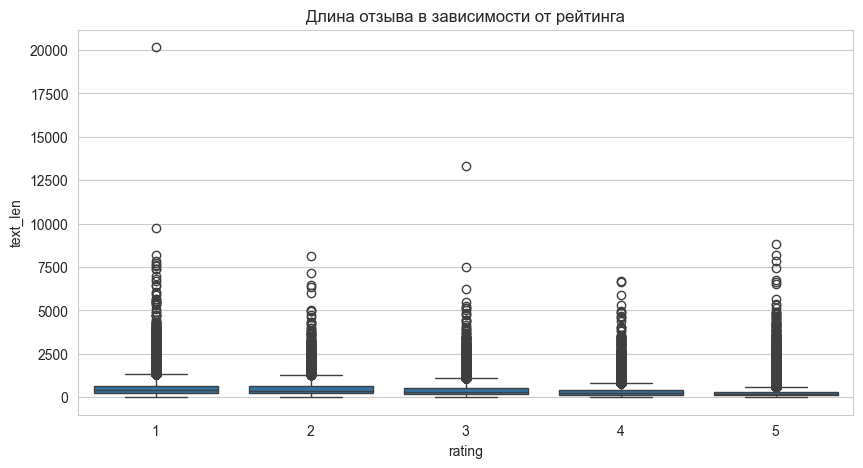

In [15]:
data['text_len'] = data['text'].str.len()
data['word_count'] = data['text'].str.split().str.len()

plt.figure(figsize=(10, 5))
sns.boxplot(data=data, x='rating', y='text_len')
plt.title('Длина отзыва в зависимости от рейтинга')

data.groupby('rating')['text_len'].agg(['mean', 'median', 'std'])

Если посмотреть на длину отзыва, можно сделать предположение что много выбросов (скорее всего спам, накрутка, реклама и тд.)

In [16]:
print("Статистика длины отзывов:")
print(data['text_len'].describe(percentiles=[0.9, 0.95, 0.99, 0.995]))

Статистика длины отзывов:
count    499799.000000
mean        303.253624
std         292.581957
min           2.000000
50%         215.000000
90%         598.000000
95%         809.000000
99%        1445.020000
99.5%      1802.000000
max       20162.000000
Name: text_len, dtype: float64


In [17]:
long_reviews = data[data['text_len'] > 1000]
print(f"\nОтзывы > 1000 символов: {len(long_reviews)} ({len(long_reviews)/len(data)*100:.2f}%)")

very_long = data[data['text_len'] > 5000]
print(f"Отзывы > 5000 символов: {len(very_long)} ({len(very_long)/len(data)*100:.3f}%)")


Отзывы > 1000 символов: 14283 (2.86%)
Отзывы > 5000 символов: 56 (0.011%)


Проанализировав количество отзывов, можно гарантированно удалить отзывы выше 5000 символов.
<br>Отзвывы от 1000 до 5000 можно оставить, так как это могут быть развернутые отзывы

In [18]:
data = data[data['text_len'] <= 5000]

Посмотрим корреляции, и выведем среднюю длину отзывап в зависимости от оценок

Корреляция Пирсона: -0.283
Корреляция Спирмена: -0.234


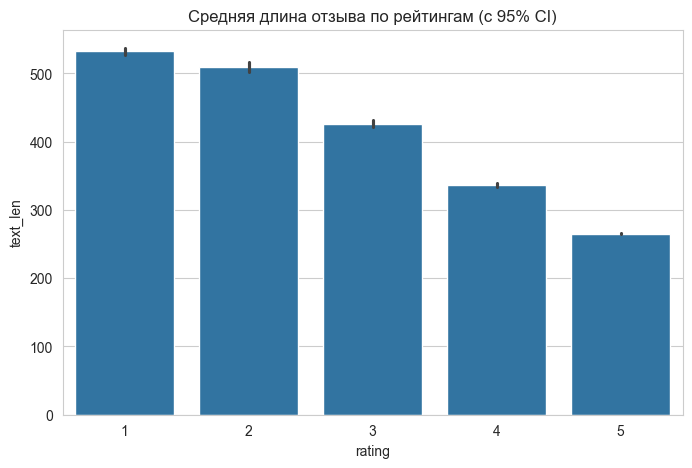

In [19]:
from scipy.stats import pearsonr, spearmanr

pearson_corr, _ = pearsonr(data['rating'], data['text_len'])
spearman_corr, _ = spearmanr(data['rating'], data['text_len'])

print(f"Корреляция Пирсона: {pearson_corr:.3f}")
print(f"Корреляция Спирмена: {spearman_corr:.3f}")

plt.figure(figsize=(8, 5))
sns.barplot(data=data, x='rating', y='text_len', errorbar='ci', ci=95)
plt.title('Средняя длина отзыва по рейтингам (с 95% CI)')
plt.show()


По графику можно сделать предположение что чем ниже оценка, тем длиннее отзывы (скорее всего люди рассписывают все проблемы)

Выберем только кафе и рестораны

In [20]:
df_cafes_restaurants = data[data['rubrics'].apply(lambda s: 'Кафе' in s or 'Ресторан' in s)]
df_cafes_restaurants.shape

(92336, 7)

In [21]:
df_cafes_restaurants.isnull().sum()

address         0
name_ru       176
rating          0
rubrics         0
text            0
text_len        0
word_count      0
dtype: int64

В датасете 92373 строк с ресторанами или кафе. Из них 176 строк имеют пропуски в названии заведения. Это примерно 0,0019%
<br>Следовательно можно удалить эти строки без особой потери в точности

In [22]:
df_cafes_restaurants = df_cafes_restaurants[df_cafes_restaurants['name_ru'].notnull()]
df_cafes_restaurants.shape

(92160, 7)

Разобьем оценку в тональности и проанализируем количество

In [23]:
def map_rating_to_tonality(rating):
    if rating in [1, 2]:
        return 'negative'
    elif rating == 3:
        return 'neutral'
    elif rating in [4, 5]:
        return 'positive'
    else:
        return None

df_cafes_restaurants['tonality'] = df_cafes_restaurants['rating'].apply(map_rating_to_tonality)

Распределение тональности:
tonality
positive    78192
negative     8907
neutral      5061
Name: count, dtype: int64

% позитивных: 84.8%


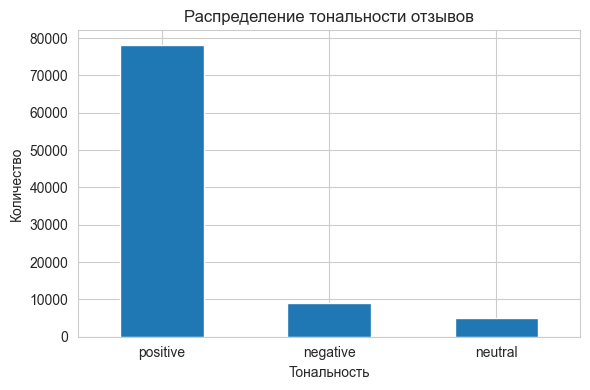

In [24]:
print("Распределение тональности:")
print(df_cafes_restaurants['tonality'].value_counts())
print(f"\n% позитивных: { (df_cafes_restaurants['tonality'] == 'positive').mean() * 100:.1f}%")


plt.figure(figsize=(6, 4))
df_cafes_restaurants['tonality'].value_counts().plot( kind='bar')
plt.title('Распределение тональности отзывов')
plt.xlabel('Тональность')
plt.ylabel('Количество')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Перейдем к предварительной предобработке текста

Очистим текст от ссылок, спецсимволов, стоп словв. Проведем токенизацию, лемматизацию и фильтрацию

In [25]:
nltk.download('stopwords', quiet=True)
stop_words = set(stopwords.words('russian'))

morph = pymorphy3.MorphAnalyzer(lang='ru')

def preprocess_text(text):

    if pd.isna(text):
        return ""
    
    text = str(text).lower()
    
    text = re.sub(r'http\S+|www\S+|@\w+|#\w+', '', text)
    text = re.sub(r'[^а-яёa-z\s]', '', text)
    
    tokens = text.split()
    lemmas = []
    for token in tokens:
        normal_form = morph.parse(token)[0].normal_form
        if normal_form not in stop_words and len(normal_form) > 2:
            lemmas.append(normal_form)
    
    return ' '.join(lemmas)

df_cafes_restaurants['text_clean'] = df_cafes_restaurants['text'].apply(preprocess_text)

df_cafes_restaurants = df_cafes_restaurants[df_cafes_restaurants['text_clean'].str.len() > 10]
print(f"Количество отзывов после очистки: {len(df_cafes_restaurants)}")

Количество отзывов после очистки: 92138


In [26]:

print("TF-IDF")
tfidf_vec = TfidfVectorizer(max_features=5000, ngram_range=(1,2), min_df=5, max_df=0.8)
X_tfidf = tfidf_vec.fit_transform(df_cafes_restaurants['text_clean'])
print(f"TF-IDF: {X_tfidf.shape}")

print("Word2Vec")
tokenized = [t.split() for t in df_cafes_restaurants['text_clean']]
w2v_model = Word2Vec(sentences=tokenized, vector_size=100, window=5, min_count=5, workers=4, sg=1, epochs=10)

def doc_vector(tokens, model, size):
    vecs = [model.wv[w] for w in tokens if w in model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(size)

X_w2v = np.array([doc_vector(t.split(), w2v_model, 100) for t in df_cafes_restaurants['text_clean']])
print(f"Word2Vec: {X_w2v.shape}")

print("FastText")
ft_model = FastText(sentences=tokenized, vector_size=100, window=5, min_count=5, workers=4, epochs=10)
X_ft = np.array([doc_vector(t.split(), ft_model, 100) for t in df_cafes_restaurants['text_clean']])
print(f"FastText: {X_ft.shape}")

print("RuBERT (подвыборка 5000)")
sample_idx = df_cafes_restaurants.sample(n=5000, random_state=42).index
df_sample = df_cafes_restaurants.loc[sample_idx].copy()

tokenizer = AutoTokenizer.from_pretrained("DeepPavlov/rubert-base-cased")
model_bert = AutoModel.from_pretrained("DeepPavlov/rubert-base-cased")

def get_bert_embedding(text, tokenizer, model, max_len=128):
    inputs = tokenizer(text, return_tensors='pt', truncation=True, max_length=max_len, padding='max_length')
    with torch.no_grad():
        outputs = model(**inputs)
    mask = inputs['attention_mask'].bool()
    hidden = outputs.last_hidden_state[mask].unsqueeze(0)
    return hidden.mean(dim=1).squeeze().numpy()

X_bert = np.array([get_bert_embedding(t, tokenizer, model_bert) for t in tqdm(df_sample['text_clean'])])
print(f"RuBERT: {X_bert.shape}")

TF-IDF
TF-IDF: (92138, 5000)
Word2Vec
Word2Vec: (92138, 100)
FastText
FastText: (92138, 100)
RuBERT (подвыборка 5000)


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 35788.80it/s]
BertModel LOAD REPORT from: DeepPavlov/rubert-base-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
100%|███

RuBERT: (5000, 768)


Разделим выборку на train и test учитывавая дисбаланс

In [ ]:

le = LabelEncoder()
y = le.fit_transform(df_cafes_restaurants['tonality'])

X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)

X_train_w2v, X_test_w2v, y_train_w2v, y_test_w2v = train_test_split(
    X_w2v, y, test_size=0.2, random_state=42, stratify=y
)

def balance_dataset(X, y, random_state=42):
    df_tmp = pd.DataFrame({'target': y})
    if hasattr(X, 'toarray'):
        df_tmp['data'] = list(X.toarray())
    else:
        df_tmp['data'] = list(X)
    
    min_count = df_tmp['target'].value_counts().min()
    balanced = df_tmp.groupby('target').sample(n=min_count, random_state=random_state)
    
    if hasattr(X, 'toarray'):
        X_balanced = np.array(balanced['data'].tolist())
    else:
        X_balanced = np.stack(balanced['data'].values)
    y_balanced = balanced['target'].values
    return X_balanced, y_balanced

X_train_tfidf_bal, y_train_bal = balance_dataset(X_train_tfidf, y_train)
X_train_w2v_bal, y_train_w2v_bal = balance_dataset(X_train_w2v, y_train_w2v)

print(f"Train (TF-IDF) после балансировки: {len(y_train_bal)} примеров")
print(f"Распределение классов в train: {pd.Series(y_train_bal).value_counts().to_dict()}")
print(f"Test (TF-IDF) без изменений: {len(y_test)} примеров")
print(f"Распределение классов в test: {pd.Series(y_test).value_counts().to_dict()}")

y_sample = le.transform(df_sample['tonality'])
X_train_bert, X_test_bert, y_train_bert, y_test_bert = train_test_split(
    X_bert, y_sample, test_size=0.2, random_state=42, stratify=y_sample
)
X_train_bert_bal, y_train_bert_bal = balance_dataset(X_train_bert, y_train_bert)

✅ Train (TF-IDF) после балансировки: 12147 примеров
✅ Распределение классов в train: {0: 4049, 1: 4049, 2: 4049}
✅ Test (TF-IDF) без изменений: 18428 примеров
✅ Распределение классов в test: {2: 15635, 0: 1781, 1: 1012}


In [ ]:
models = {
    'LogReg_TFIDF': (
        LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
        X_train_tfidf_bal, X_test_tfidf, y_train_bal, y_test
    ),
    'NaiveBayes_TFIDF': (
        MultinomialNB(),
        X_train_tfidf_bal, X_test_tfidf, y_train_bal, y_test
    ),
    'RandomForest_W2V': (
        RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
        X_train_w2v_bal, X_test_w2v, y_train_w2v_bal, y_test_w2v
    )
}

results = {}

for name, (clf, X_tr, X_te, y_tr, y_te) in models.items():
    print(f"\n{name}")
    clf.fit(X_tr, y_tr)
    y_pred = clf.predict(X_te)
    
    results[name] = {
        'accuracy': accuracy_score(y_te, y_pred),
        'precision': precision_score(y_te, y_pred, average='macro'),
        'recall': recall_score(y_te, y_pred, average='macro'),
        'f1': f1_score(y_te, y_pred, average='macro'),
        'y_true': y_te,
        'y_pred': y_pred
    }
    print(f"Accuracy: {results[name]['accuracy']:.3f} | F1: {results[name]['f1']:.3f}")


🔹 LogReg_TFIDF
   Accuracy: 0.840 | F1: 0.649

🔹 NaiveBayes_TFIDF
   Accuracy: 0.817 | F1: 0.628

🔹 RandomForest_W2V
   Accuracy: 0.825 | F1: 0.633


In [29]:
print("Обучение CatBoost на TF-IDF")

cat_model = CatBoostClassifier(
    verbose=0, random_state=42,
    iterations=500, learning_rate=0.1, depth=6,
    loss_function='MultiClass', eval_metric='MultiClass'
)

cat_model.fit(X_train_tfidf_bal, y_train_bal, eval_set=[(X_test_tfidf, y_test)])

y_pred_cat = cat_model.predict(X_test_tfidf)

results['CatBoost_TFIDF'] = {
    'accuracy': accuracy_score(y_test, y_pred_cat),
    'precision': precision_score(y_test, y_pred_cat, average='macro'),
    'recall': recall_score(y_test, y_pred_cat, average='macro'),
    'f1': f1_score(y_test, y_pred_cat, average='macro'),
    'y_true': y_test,
    'y_pred': y_pred_cat
}

print(f"CatBoost: Accuracy={results['CatBoost_TFIDF']['accuracy']:.3f}, F1={results['CatBoost_TFIDF']['f1']:.3f}")

Обучение CatBoost на TF-IDF
CatBoost: Accuracy=0.819, F1=0.627


In [30]:
class TextDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X if isinstance(X, np.ndarray) else X.toarray())
        self.y = torch.LongTensor(y)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

train_ds = TextDataset(X_train_w2v_bal, y_train_w2v_bal)
test_ds = TextDataset(X_test_w2v, y_test_w2v)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=64)
criterion = nn.CrossEntropyLoss()

print("Обучение MLP")
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_classes=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(hidden_dim, hidden_dim//2), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(hidden_dim//2, num_classes)
        )
    def forward(self, x): return self.net(x)

mlp = MLP(input_dim=100)
optimizer = torch.optim.Adam(mlp.parameters(), lr=0.001)

mlp.train()
for epoch in range(10):
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        loss = criterion(mlp(X_batch), y_batch)
        loss.backward()
        optimizer.step()

mlp.eval()
preds_mlp, true_mlp = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        p = torch.argmax(mlp(X_batch), dim=1)
        preds_mlp.extend(p.numpy())
        true_mlp.extend(y_batch.numpy())

results['MLP_W2V'] = {
    'accuracy': accuracy_score(true_mlp, preds_mlp),
    'precision': precision_score(true_mlp, preds_mlp, average='macro'),
    'recall': recall_score(true_mlp, preds_mlp, average='macro'),
    'f1': f1_score(true_mlp, preds_mlp, average='macro')
}
print(f"MLP: Accuracy={results['MLP_W2V']['accuracy']:.3f}, F1={results['MLP_W2V']['f1']:.3f}")

print("Обучение RNN")
class SimpleRNN(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_classes=3):
        super().__init__()
        self.rnn = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, num_classes)
    def forward(self, x):
        x = x.unsqueeze(1)
        _, (h_n, _) = self.rnn(x)
        return self.fc(h_n[-1])

rnn = SimpleRNN(input_dim=100)
opt_rnn = torch.optim.Adam(rnn.parameters(), lr=0.001)

rnn.train()
for epoch in range(10):
    for X_batch, y_batch in train_loader:
        opt_rnn.zero_grad()
        loss = criterion(rnn(X_batch), y_batch)
        loss.backward()
        opt_rnn.step()

rnn.eval()
preds_rnn, true_rnn = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        p = torch.argmax(rnn(X_batch), dim=1)
        preds_rnn.extend(p.numpy())
        true_rnn.extend(y_batch.numpy())

results['RNN_W2V'] = {
    'accuracy': accuracy_score(true_rnn, preds_rnn),
    'precision': precision_score(true_rnn, preds_rnn, average='macro'),
    'recall': recall_score(true_rnn, preds_rnn, average='macro'),
    'f1': f1_score(true_rnn, preds_rnn, average='macro')
}
print(f"RNN: Accuracy={results['RNN_W2V']['accuracy']:.3f}, F1={results['RNN_W2V']['f1']:.3f}")

Обучение MLP
MLP: Accuracy=0.850, F1=0.658
Обучение RNN
RNN: Accuracy=0.817, F1=0.640


Рейтинг моделей по F1-macro:


,model,accuracy,precision,recall,f1_macro
4,MLP_W2V,0.850,0.663,0.727,0.658
0,LogReg_TFIDF,0.840,0.629,0.731,0.649
5,RNN_W2V,0.817,0.636,0.732,0.640
2,RandomForest_W2V,0.825,0.625,0.709,0.633
1,NaiveBayes_TFIDF,0.817,0.604,0.723,0.628
3,CatBoost_TFIDF,0.819,0.606,0.717,0.627


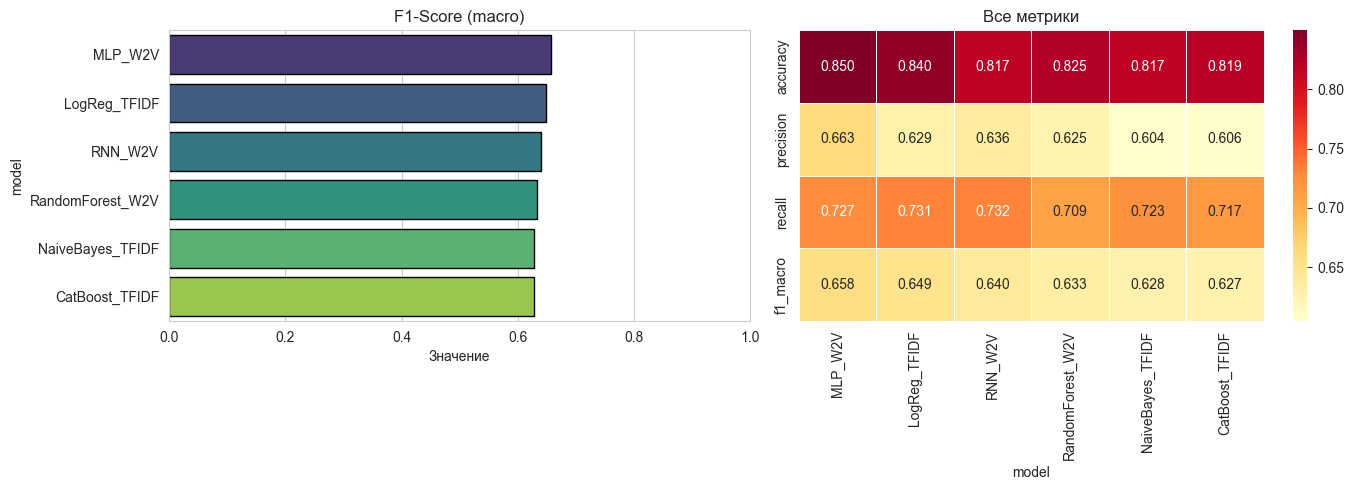

Лучшая модель: MLP_W2V

Метрики:
  Accuracy:  0.850
  Precision: 0.663
  Recall:    0.727
  F1-Score:  0.658



In [36]:
results_df = pd.DataFrame([
    {
        'model': name,
        'accuracy': res['accuracy'],
        'precision': res['precision'],
        'recall': res['recall'],
        'f1_macro': res['f1']
    }
    for name, res in results.items()
]).sort_values('f1_macro', ascending=False)

print("Рейтинг моделей по F1-macro:")
display(results_df.style
        .format('{:.3f}', subset=['accuracy','precision','recall','f1_macro'])
        .background_gradient(cmap='Greens', subset=['f1_macro']))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=results_df, x='f1_macro', y='model', ax=axes[0], palette='viridis', edgecolor='black')
axes[0].set_title('F1-Score (macro)')
axes[0].set_xlabel('Значение')
axes[0].set_xlim(0, 1)

sns.heatmap(
    results_df.set_index('model')[['accuracy','precision','recall','f1_macro']].T,
    annot=True, fmt='.3f', cmap='YlOrRd', ax=axes[1], linewidths=0.5
)
axes[1].set_title('Все метрики')

plt.tight_layout()
plt.show()

best_model_name = results_df.iloc[0]['model']
best_res = results[best_model_name]

print(f"Лучшая модель: {best_model_name}")
print()
print("Метрики:")
print(f"  Accuracy:  {best_res['accuracy']:.3f}")
print(f"  Precision: {best_res['precision']:.3f}")
print(f"  Recall:    {best_res['recall']:.3f}")
print(f"  F1-Score:  {best_res['f1']:.3f}")
print()

if 'y_true' in best_res and 'y_pred' in best_res:
    print("Classification Report:")
    print(classification_report(
        best_res['y_true'], 
        best_res['y_pred'], 
        target_names=['negative', 'neutral', 'positive'],
        zero_division=0
    ))
    
    plt.figure(figsize=(6, 5))
    cm = confusion_matrix(best_res['y_true'], best_res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['negative', 'neutral', 'positive'], 
                yticklabels=['negative', 'neutral', 'positive'])
    plt.title(f'Confusion Matrix: {best_model_name}')
    plt.ylabel('Истинный класс')
    plt.xlabel('Предсказанный класс')
    plt.tight_layout()
    plt.show()

In [37]:
best = results_df.iloc[0]
print(f"""
 Лучшая модель: {best['model']}
Метрики:
    Accuracy:  {best['accuracy']:.3f}
    Precision: {best['precision']:.3f}
    Recall:    {best['recall']:.3f}
    F1-Score:  {best['f1_macro']:.3f}
""")

if 'TFIDF' in best['model']:
    joblib.dump({
        'model': cat_model if 'CatBoost' in best['model'] else LogisticRegression(),
        'vectorizer': tfidf_vec,
        'encoder': le,
        'preprocessor': preprocess_text
    }, 'best_model_tfidf.pkl')
else:
    joblib.dump({
        'model': 'MLP/RNN (PyTorch weights not saved here)',
        'encoder': le,
        'preprocessor': preprocess_text
    }, 'best_model_nn.pkl')


 Лучшая модель: MLP_W2V
Метрики:
    Accuracy:  0.850
    Precision: 0.663
    Recall:    0.727
    F1-Score:  0.658

